## LSTM and CNN With sliding window

### LIbrary and Paths Imports

In [103]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time
import os
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (LSTM, Dense, Input, Dropout, Conv1D, MaxPooling1D, Flatten)
from tensorflow.keras.callbacks import (EarlyStopping, ModelCheckpoint)
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import recall_score, confusion_matrix, classification_report
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import GaussianNoise
from tensorflow.keras.layers import BatchNormalization

import warnings
warnings.filterwarnings("ignore")
from pathlib import Path
import random

WINDOW_SIZE = 10
N_CLASSES = 3
BATCH_SIZE = 128
EPOCHS = 100
LEARNING_RATE = 0.001

tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

BASE_PATH = Path.cwd().parent
SCALED_PATH = BASE_PATH / "data" / "model" / "scaled"
MODEL_PATH = BASE_PATH / "models"
ASSETS_PATH = BASE_PATH/ "assets"


### Data Loading

In [104]:
# Load data that has been scaled.
# Loading the Robust Scaled data and then, switch to Standard Scaled data later for comparison.

# Load scaled data (ROBUST versions)
X_train = pd.read_csv(SCALED_PATH / "X_train_robust.csv")
X_val   = pd.read_csv(SCALED_PATH / "X_val_robust.csv")
X_test  = pd.read_csv(SCALED_PATH / "X_test_robust.csv")

y_train = pd.read_csv(SCALED_PATH / "y_train.csv").squeeze()
y_val   = pd.read_csv(SCALED_PATH / "y_val.csv").squeeze()
y_test  = pd.read_csv(SCALED_PATH / "y_test.csv").squeeze()

train_meta = pd.read_csv(SCALED_PATH / "train_meta.csv")
val_meta   = pd.read_csv(SCALED_PATH / "val_meta.csv")
test_meta  = pd.read_csv(SCALED_PATH / "test_meta.csv")

train_scenario_ids = train_meta["scenario_id"].values
train_timesteps    = train_meta["timestep"].values

val_scenario_ids = val_meta["scenario_id"].values
val_timesteps    = val_meta["timestep"].values

test_scenario_ids = test_meta["scenario_id"].values
test_timesteps    = test_meta["timestep"].values


N_FEATURES = X_train.shape[1]

# Verify shapes
print("DATA SHAPES")
print("-" * 30)
print(f"X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"X_val  : {X_val.shape}   | y_val  : {y_val.shape}")
print(f"X_test : {X_test.shape}  | y_test : {y_test.shape}")
print(f"Features: {N_FEATURES}")
print(f"Window size: {WINDOW_SIZE}")
print(f"Input shape per sequence: ({WINDOW_SIZE}, {N_FEATURES})")

DATA SHAPES
------------------------------
X_train: (23100, 126) | y_train: (23100,)
X_val  : (4200, 126)   | y_val  : (4200,)
X_test : (4200, 126)  | y_test : (4200,)
Features: 126
Window size: 10
Input shape per sequence: (10, 126)


### Building Sequence using Scenario Id

In [105]:
def build_sequences(X, y, window_size):
    """
    Slide a window over a single scenario's timesteps.
    Label = label of the LAST timestep in each window.
    """
    sequences = []
    labels = []

    for i in range(window_size, len(X) + 1):
        window = X[i - window_size : i]
        label  = y.iloc[i - 1]
        sequences.append(window)
        labels.append(label)

    return np.array(sequences), np.array(labels)

def build_sequences_safe(X_df, y_series, scenario_ids, window_size=WINDOW_SIZE):
    """
    Calls build_sequences per scenario so windows never
    span two different scenarios.
    """
    all_X, all_y = [], []

    for scenario in np.unique(scenario_ids):
        mask     = scenario_ids == scenario
        X_sc     = X_df[mask]
        y_sc     = y_series[mask]

        # skip scenarios too short to fill one window
        if len(X_sc) < window_size:
            continue

        Xs, ys = build_sequences(X_sc, y_sc, window_size)
        all_X.append(Xs)
        all_y.append(ys)

    return np.concatenate(all_X), np.concatenate(all_y)

X_train_seq, y_train_seq = build_sequences_safe(
    X_train, y_train, train_scenario_ids)

X_val_seq, y_val_seq = build_sequences_safe(
    X_val, y_val, val_scenario_ids)

X_test_seq, y_test_seq = build_sequences_safe(
    X_test, y_test, test_scenario_ids)

print("SEQUENCE SHAPES")
print("-" * 30)
print(f"X_train_seq : {X_train_seq.shape}")
print(f"X_val_seq   : {X_val_seq.shape}")
print(f"X_test_seq  : {X_test_seq.shape}")


SEQUENCE SHAPES
------------------------------
X_train_seq : (22803, 10, 126)
X_val_seq   : (4146, 10, 126)
X_test_seq  : (4146, 10, 126)


### One Hot Encoding using to_categorical

In [106]:
# Keras softmax needs (n, 3)
y_train_cat = to_categorical(y_train_seq, num_classes=N_CLASSES)
y_val_cat   = to_categorical(y_val_seq,   num_classes=N_CLASSES)
y_test_cat  = to_categorical(y_test_seq,  num_classes=N_CLASSES)

print("\nONE-HOT SHAPES")
print("-" * 30)
print(f"y_train_cat : {y_train_cat.shape}")
print(f"y_val_cat   : {y_val_cat.shape}")
print(f"y_test_cat  : {y_test_cat.shape}")


ONE-HOT SHAPES
------------------------------
y_train_cat : (22803, 3)
y_val_cat   : (4146, 3)
y_test_cat  : (4146, 3)


### Building MLP (Multi layer Perceptron) -> Base Model

In [107]:
def build_mlp(input_shape,n_classes, learning_rate):
    model = Sequential([
        Input(shape = input_shape),
        Flatten(),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.2),
        Dense(n_classes, activation = 'softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate, clipnorm=1.0),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

mlp_model = build_mlp(
    input_shape=(WINDOW_SIZE, X_train_seq.shape[2]),
    n_classes = N_CLASSES,
    learning_rate=0.0001
)

mlp_model.summary()

Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_14 (Flatten)            │ (None, 1260)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_55 (Dense)                │ (None, 256)            │       322,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_48          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_62 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_56 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_49          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_63 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_57 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_50          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_64 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_58 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 365,955 (1.40 MB)

 Trainable params: 365,059 (1.39 MB)

 Non-trainable params: 896 (3.50 KB)

### Build LSTM and CNN models

In [108]:
def build_lstm(input_shape, n_classes, learning_rate):
    model = Sequential([
        Input(shape=input_shape),
        GaussianNoise(0.005),

        LSTM(128,
             return_sequences=True,
             kernel_regularizer=l2(0.0005),
             recurrent_regularizer=l2(0.0005)),
        BatchNormalization(),
        Dropout(0.3),

        LSTM(64,
             return_sequences=False,
             kernel_regularizer=l2(0.0005),
             recurrent_regularizer=l2(0.0005)),
        BatchNormalization(),
        Dropout(0.3),

        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(n_classes, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

lstm_model = build_lstm(
    input_shape=(WINDOW_SIZE, X_train_seq.shape[2]),
    n_classes=N_CLASSES,
    learning_rate = LEARNING_RATE
)

lstm_model.summary()

Model: "sequential_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gaussian_noise_7                │ (None, 10, 126)        │             0 │
│ (GaussianNoise)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_14 (LSTM)                  │ (None, 10, 128)        │       130,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_51          │ (None, 10, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_65 (Dropout)            │ (None, 10, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_15 (LSTM)                  │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_52          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_66 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_59 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_67 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_60 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 182,915 (714.51 KB)

 Trainable params: 182,531 (713.01 KB)

 Non-trainable params: 384 (1.50 KB)

In [109]:
def build_cnn(input_shape, n_classes, learning_rate):

    model = Sequential([
        Conv1D(filters=64, kernel_size=3,
               activation="relu",
               kernel_regularizer=l2(0.0005),
               input_shape=input_shape),

        BatchNormalization(),   # to reduce internal covariance shift
        MaxPooling1D(pool_size=2),
        Dropout(0.3),

        Conv1D(filters= 128, kernel_size=3,
               activation="relu",
               kernel_regularizer=l2(0.0005)),
        BatchNormalization(),
        Dropout(0.3),

        Flatten(),   # flattening to 1D vector
        Dense(64, activation="relu"),
        Dropout(0.2),
        Dense(n_classes, activation="softmax")
    ])

    model.compile(
        optimizer=Adam(learning_rate, clipnorm=1.0),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

cnn_model = build_cnn(
    input_shape = (WINDOW_SIZE, X_train_seq.shape[2]),
    n_classes = N_CLASSES,
    learning_rate = LEARNING_RATE
)

cnn_model.summary()

Model: "sequential_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_14 (Conv1D)              │ (None, 8, 64)          │        24,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_53          │ (None, 8, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_7 (MaxPooling1D)  │ (None, 4, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_68 (Dropout)            │ (None, 4, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_15 (Conv1D)              │ (None, 2, 128)         │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_54          │ (None, 2, 128)         │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_69 (Dropout)            │ (None, 2, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_15 (Flatten)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_61 (Dense)                │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_70 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_62 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 66,371 (259.26 KB)

 Trainable params: 65,987 (257.76 KB)

 Non-trainable params: 384 (1.50 KB)

### Model Callbacks

In [110]:
def get_callbacks(model_name):
    return[
        EarlyStopping(
            monitor = "val_loss",
            patience = 15,
            restore_best_weights = True,
            min_delta = 0.001,
        ),
        ModelCheckpoint(
            filepath= MODEL_PATH/ f"{model_name}_best_model.keras",
            monitor = "val_loss",
            save_best_only = True,
            mode = "min",
            verbose = 1
        )
    ]

### Training MLP

In [111]:
start_time = time.time()
print(start_time)

mlp_history = mlp_model.fit(
    X_train_seq, y_train_cat,
    validation_data=(X_val_seq, y_val_cat),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks("mlp"),
    verbose=1
)

end_time = time.time()
print(f"\nTraining time : {(end_time - start_time):.1f}s  "
      f"({(end_time - start_time) / 60:.1f} mins)")
print(f"Stopped at epoch: {len(mlp_history.history['loss'])}")

1777832190.263017
Epoch 1/100
174/179 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6050 - loss: 0.9115
Epoch 1: val_loss improved from None to 1.30050, saving model to /home/local-host/IdeaProjects/ai-pipeline-leak-detection/ml_service/models/mlp_best_model.keras

Epoch 1: finished saving model to /home/local-host/IdeaProjects/ai-pipeline-leak-detection/ml_service/models/mlp_best_model.keras
179/179 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.7326 - loss: 0.6298 - val_accuracy: 0.5000 - val_loss: 1.3005
Epoch 2/100
178/179 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9081 - loss: 0.2627
Epoch 2: val_loss did not improve from 1.30050
179/179 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9219 - loss: 0.2255 - val_accuracy: 0.5000 - val_loss: 1.6256
Epoch 3/100
176/179 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9509 - loss: 0.1496
Epoch 3: val_loss did not improve from 1.30050
179/179 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9598 - loss: 0.1279 - val_accuracy: 0.5000 - 

### Training LSTM

In [112]:
start_time = time.time()
print(start_time)

lstm_history = lstm_model.fit(
    X_train_seq, y_train_cat,
    validation_data=(X_val_seq, y_val_cat),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks("lstm"),
    verbose=1
)

end_time = time.time()
print(f"\nTraining time : {(end_time - start_time):.1f}s  "
      f"({(end_time - start_time) / 60:.1f} mins)")
print(f"Stopped at epoch: {len(lstm_history.history['loss'])}")

1777832224.686143
Epoch 1/100
177/179 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9069 - loss: 0.5262
Epoch 1: val_loss improved from None to 0.61473, saving model to /home/local-host/IdeaProjects/ai-pipeline-leak-detection/ml_service/models/lstm_best_model.keras

Epoch 1: finished saving model to /home/local-host/IdeaProjects/ai-pipeline-leak-detection/ml_service/models/lstm_best_model.keras
179/179 ━━━━━━━━━━━━━━━━━━━━ 11s 39ms/step - accuracy: 0.9762 - loss: 0.3176 - val_accuracy: 0.8152 - val_loss: 0.6147
Epoch 2/100
177/179 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.9996 - loss: 0.1718
Epoch 2: val_loss improved from 0.61473 to 0.59270, saving model to /home/local-host/IdeaProjects/ai-pipeline-leak-detection/ml_service/models/lstm_best_model.keras

Epoch 2: finished saving model to /home/local-host/IdeaProjects/ai-pipeline-leak-detection/ml_service/models/lstm_best_model.keras
179/179 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.9997 - loss: 0.1523 - val_accuracy: 0.80

### Training CNN

In [113]:
start_time = time.time()
print(start_time)

cnn_history = cnn_model.fit(
    X_train_seq, y_train_cat,
    validation_data=(X_val_seq, y_val_cat),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks("cnn"),
    verbose=1
)

end_time = time.time()
print(f"\nTraining time : {(end_time - start_time):.1f}s  "
      f"({(end_time - start_time) / 60:.1f} mins)")
print(f"Stopped at epoch: {len(cnn_history.history['loss'])}")

1777832488.4749515
Epoch 1/100
177/179 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8026 - loss: 0.4996
Epoch 1: val_loss improved from None to 107860120.00000, saving model to /home/local-host/IdeaProjects/ai-pipeline-leak-detection/ml_service/models/cnn_best_model.keras

Epoch 1: finished saving model to /home/local-host/IdeaProjects/ai-pipeline-leak-detection/ml_service/models/cnn_best_model.keras
179/179 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9238 - loss: 0.2408 - val_accuracy: 0.8333 - val_loss: 107860120.0000
Epoch 2/100
176/179 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9966 - loss: 0.0690
Epoch 2: val_loss did not improve from 107860120.00000
179/179 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9971 - loss: 0.0649 - val_accuracy: 0.8333 - val_loss: 125791352.0000
Epoch 3/100
175/179 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9979 - loss: 0.0541
Epoch 3: val_loss improved from 107860120.00000 to 93082696.00000, saving model to /home/local-host/IdeaProjects/a

### Plot Training accuracy

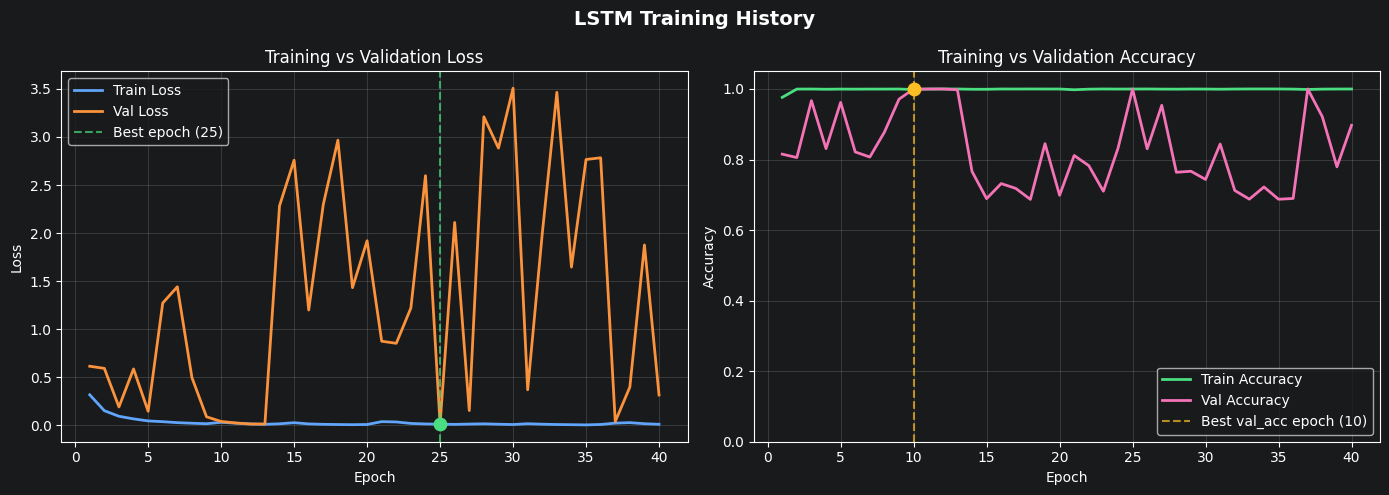


LSTM TRAINING DIAGNOSIS
----------------------------------------
Total epochs run      : 40
Best val_loss         : 0.0119  (epoch 25)
Best val_accuracy     : 1.0000  (epoch 10)
Train accuracy @ best : 0.9998
Val accuracy   @ best : 1.0000
Train/Val gap         : -0.0002  OK


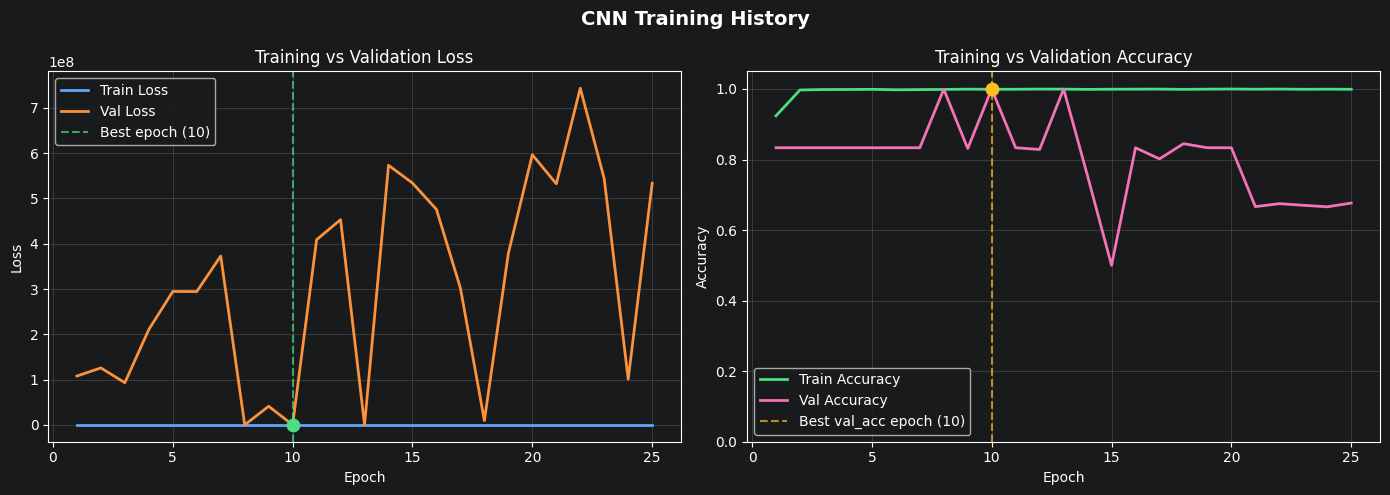


CNN TRAINING DIAGNOSIS
----------------------------------------
Total epochs run      : 25
Best val_loss         : 0.0152  (epoch 10)
Best val_accuracy     : 1.0000  (epoch 10)
Train accuracy @ best : 0.9990
Val accuracy   @ best : 1.0000
Train/Val gap         : -0.0010  OK


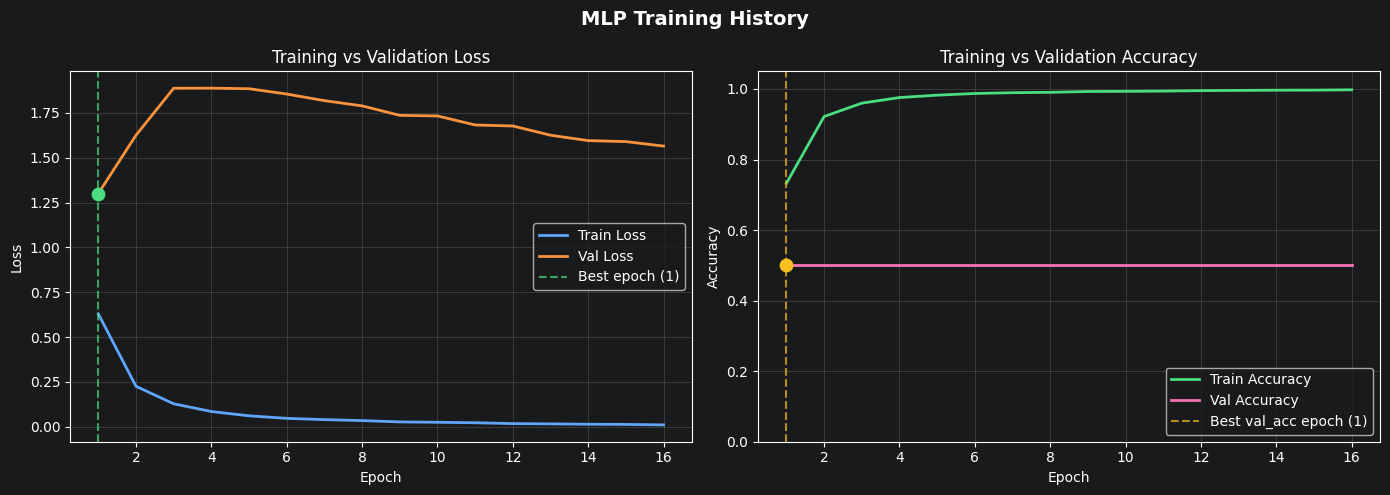


MLP TRAINING DIAGNOSIS
----------------------------------------
Total epochs run      : 16
Best val_loss         : 1.3005  (epoch 1)
Best val_accuracy     : 0.5000  (epoch 1)
Train accuracy @ best : 0.7326
Val accuracy   @ best : 0.5000
Train/Val gap         : 0.2326  OVERFIT


In [114]:
ASSETS_PATH.mkdir(parents=True, exist_ok=True)

def plot_history(history, model_name):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"{model_name} Training History", fontsize=14, fontweight="bold")

    epochs_range = range(1, len(history.history["loss"]) + 1)

    # best epoch indices
    best_epoch_idx     = int(np.argmin(history.history["val_loss"]))
    best_epoch         = best_epoch_idx + 1
    best_val_loss      = history.history["val_loss"][best_epoch_idx]

    best_val_acc_idx   = int(np.argmax(history.history["val_accuracy"]))
    best_val_acc_epoch = best_val_acc_idx + 1
    best_val_acc       = history.history["val_accuracy"][best_val_acc_idx]

    # gap at best epoch — not final epoch
    gap = (history.history['accuracy'][best_epoch_idx] -
           history.history['val_accuracy'][best_epoch_idx])

    # ── Subplot 1: Loss
    ax1.plot(epochs_range, history.history["loss"],
             label="Train Loss", color="#60a5fa", linewidth=2)
    ax1.plot(epochs_range, history.history["val_loss"],
             label="Val Loss",   color="#fb923c", linewidth=2)

    ax1.axvline(best_epoch, color="#4ade80", linestyle="--", alpha=0.7,
                label=f"Best epoch ({best_epoch})")
    ax1.scatter([best_epoch], [best_val_loss], color="#4ade80", s=80, zorder=5)

    ax1.set_title("Training vs Validation Loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.legend()
    ax1.grid(alpha=0.3)

    #  Subplot 2: Accuracy
    ax2.plot(epochs_range, history.history["accuracy"],
             label="Train Accuracy", color="#4ade80", linewidth=2)
    ax2.plot(epochs_range, history.history["val_accuracy"],
             label="Val Accuracy",   color="#f472b6", linewidth=2)

    ax2.axvline(best_val_acc_epoch, color="#fbbf24", linestyle="--", alpha=0.7,
                label=f"Best val_acc epoch ({best_val_acc_epoch})")
    ax2.scatter([best_val_acc_epoch], [best_val_acc],
                color="#fbbf24", s=80, zorder=5)

    ax2.set_title("Training vs Validation Accuracy")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")
    ax2.set_ylim([0, 1.05])
    ax2.legend()
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    save_path = ASSETS_PATH / f"{model_name.lower()}_training_history.png"
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

    # Diagnosis at best epoch
    print(f"\n{model_name} TRAINING DIAGNOSIS")
    print("-" * 40)
    print(f"Total epochs run      : {len(history.history['loss'])}")
    print(f"Best val_loss         : {best_val_loss:.4f}  (epoch {best_epoch})")
    print(f"Best val_accuracy     : {best_val_acc:.4f}  (epoch {best_val_acc_epoch})")
    print(f"Train accuracy @ best : {history.history['accuracy'][best_epoch_idx]:.4f}")
    print(f"Val accuracy   @ best : {history.history['val_accuracy'][best_epoch_idx]:.4f}")
    print(f"Train/Val gap         : {gap:.4f}  {'OVERFIT' if gap > 0.05 else 'OK'}")


# ── Call for all three models
plot_history(lstm_history, "LSTM")
plot_history(cnn_history,  "CNN")
plot_history(mlp_history,  "MLP")

### Evaluate on Validation set

LSTM — VALIDATION SET RESULTS
              precision    recall  f1-score   support

      Normal     1.0000    1.0000    1.0000      1382
        Leak     1.0000    1.0000    1.0000      1382
    Blockage     1.0000    1.0000    1.0000      1382

    accuracy                         1.0000      4146
   macro avg     1.0000    1.0000    1.0000      4146
weighted avg     1.0000    1.0000    1.0000      4146



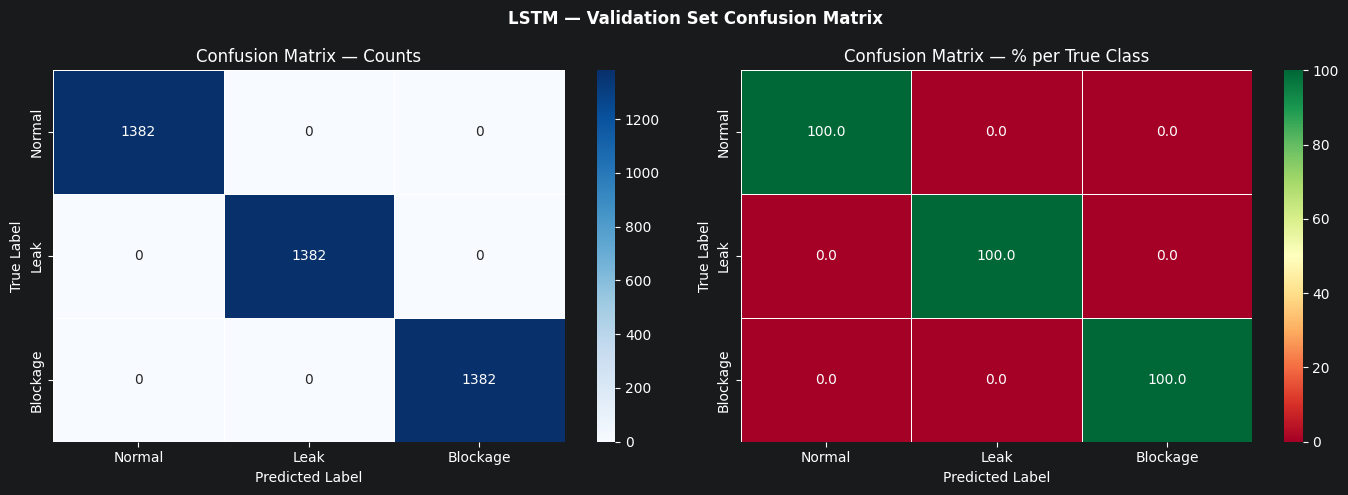

CNN — VALIDATION SET RESULTS
              precision    recall  f1-score   support

      Normal     1.0000    1.0000    1.0000      1382
        Leak     1.0000    1.0000    1.0000      1382
    Blockage     1.0000    1.0000    1.0000      1382

    accuracy                         1.0000      4146
   macro avg     1.0000    1.0000    1.0000      4146
weighted avg     1.0000    1.0000    1.0000      4146



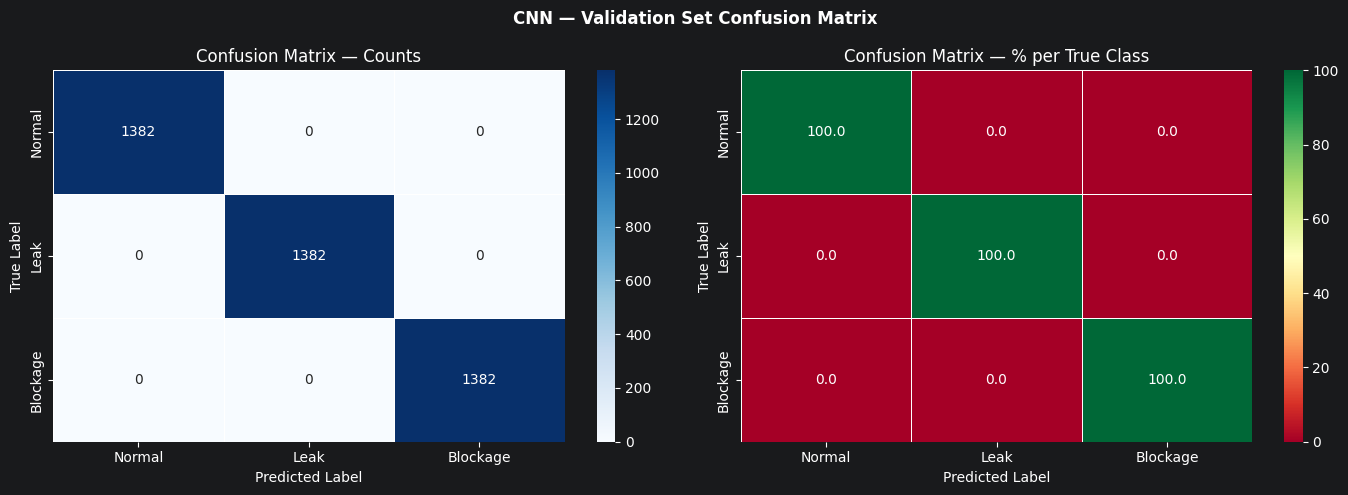

MLP — VALIDATION SET RESULTS
              precision    recall  f1-score   support

      Normal     0.0000    0.0000    0.0000      1382
        Leak     1.0000    0.5000    0.6667      1382
    Blockage     0.4000    1.0000    0.5714      1382

    accuracy                         0.5000      4146
   macro avg     0.4667    0.5000    0.4127      4146
weighted avg     0.4667    0.5000    0.4127      4146



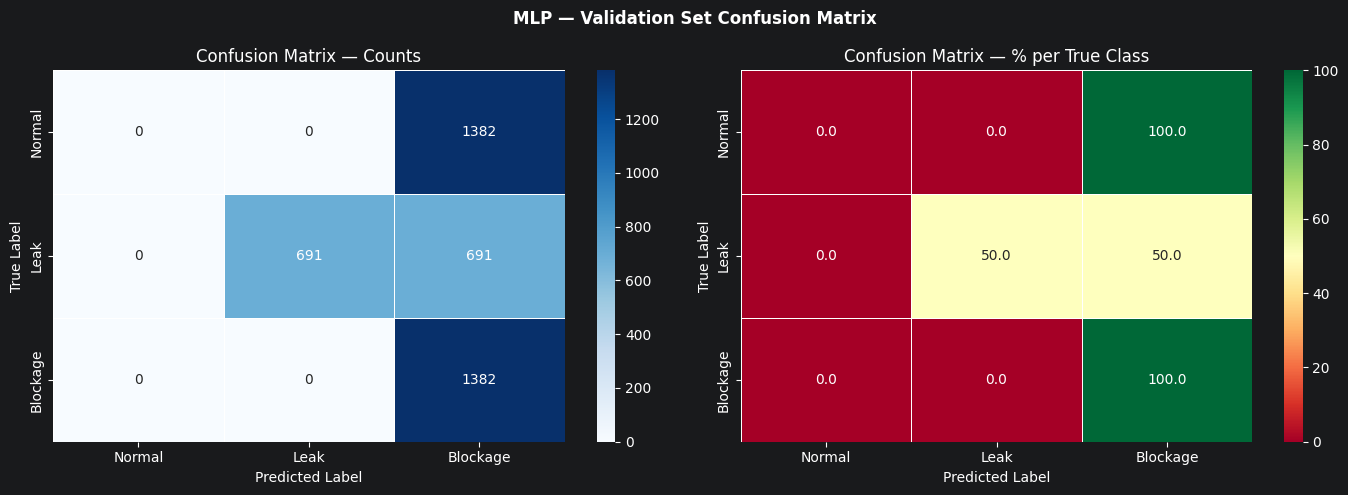

In [115]:
def evaluate_model(model, model_name, X_val_seq, y_val_cat):
    """
    - Classification report
    - Confusion matrix (counts + percentages)
    - Leak recall extraction
    - Saves confusion matrix to assets folder
    """
    CLASS_NAMES = ["Normal", "Leak", "Blockage"]

    # Predict
    y_pred_prob = model.predict(X_val_seq, verbose=0)
    y_pred      = np.argmax(y_pred_prob, axis=1)
    y_true      = np.argmax(y_val_cat,   axis=1)

    # Classification Report
    print("=" * 50)
    print(f"{model_name} — VALIDATION SET RESULTS")
    print("=" * 50)
    print(classification_report(
        y_true, y_pred,
        target_names=CLASS_NAMES,
        digits=4
    ))

    # Leak Recall
    leak_recall = recall_score(y_true, y_pred, labels=[1], average=None)[0]

    # Confusion Matrix
    cm     = confusion_matrix(y_true, y_pred)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                ax=axes[0], linewidths=0.5)
    axes[0].set_title("Confusion Matrix — Counts")
    axes[0].set_ylabel("True Label")
    axes[0].set_xlabel("Predicted Label")

    sns.heatmap(cm_pct, annot=True, fmt=".1f", cmap="RdYlGn",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                ax=axes[1], linewidths=0.5, vmin=0, vmax=100)
    axes[1].set_title("Confusion Matrix — % per True Class")
    axes[1].set_ylabel("True Label")
    axes[1].set_xlabel("Predicted Label")

    plt.suptitle(f"{model_name} — Validation Set Confusion Matrix",
                 fontweight="bold")
    plt.tight_layout()

    save_path = ASSETS_PATH / f"{model_name.lower()}_val_confusion.png"
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

    return leak_recall


# Run for all three models
leak_recall_lstm = evaluate_model(lstm_model, "LSTM", X_val_seq, y_val_cat)
leak_recall_cnn  = evaluate_model(cnn_model,  "CNN",  X_val_seq, y_val_cat)
leak_recall_mlp  = evaluate_model(mlp_model,  "MLP",  X_val_seq, y_val_cat)


 Loaded best checkpoint: lstm_best.keras

LSTM — FINAL TEST SET RESULTS
              precision    recall  f1-score   support

      Normal     1.0000    1.0000    1.0000      1382
        Leak     0.6683    1.0000    0.8012      1382
    Blockage     1.0000    0.5036    0.6699      1382

    accuracy                         0.8345      4146
   macro avg     0.8894    0.8345    0.8237      4146
weighted avg     0.8894    0.8345    0.8237      4146



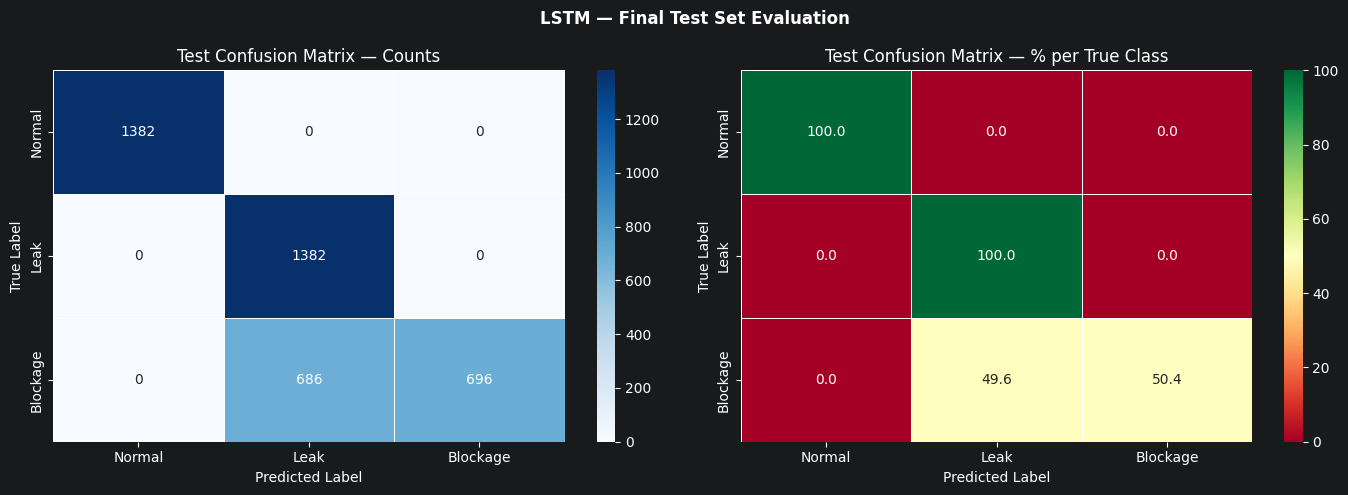

In [116]:
# Load best checkpoint
best_model = load_model(MODEL_PATH / "lstm_best_model.keras")
print(" Loaded best checkpoint: lstm_best.keras")

# Predict on test set
y_pred_prob_test = best_model.predict(X_test_seq, verbose=0)
y_pred_test      = np.argmax(y_pred_prob_test, axis=1)
y_true_test      = np.argmax(y_test_cat, axis=1)

# Final Classification Report
print("\n" + "=" * 50)
print("LSTM — FINAL TEST SET RESULTS")
print("=" * 50)
print(classification_report(
    y_true_test, y_pred_test,
    target_names=["Normal", "Leak", "Blockage"],
    digits=4
))

# Final Confusion Matrix
cm_test     = confusion_matrix(y_true_test, y_pred_test)
cm_test_pct = cm_test.astype(float) / cm_test.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm_test, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal", "Leak", "Blockage"],
            yticklabels=["Normal", "Leak", "Blockage"],
            ax=axes[0], linewidths=0.5)
axes[0].set_title("Test Confusion Matrix — Counts")
axes[0].set_ylabel("True Label")
axes[0].set_xlabel("Predicted Label")

sns.heatmap(cm_test_pct, annot=True, fmt=".1f", cmap="RdYlGn",
            xticklabels=["Normal", "Leak", "Blockage"],
            yticklabels=["Normal", "Leak", "Blockage"],
            ax=axes[1], linewidths=0.5, vmin=0, vmax=100)
axes[1].set_title("Test Confusion Matrix — % per True Class")
axes[1].set_ylabel("True Label")
axes[1].set_xlabel("Predicted Label")

plt.suptitle("LSTM — Final Test Set Evaluation", fontweight="bold")
plt.tight_layout()
plt.savefig("lstm_test_confusion.png", dpi=150, bbox_inches="tight")
plt.show()

In [117]:
print("Val class distribution  :", np.bincount(np.argmax(y_val_cat, axis=1)))
print("Test class distribution :", np.bincount(np.argmax(y_test_cat, axis=1)))

Val class distribution  : [1382 1382 1382]
Test class distribution : [1382 1382 1382]




LSTM and CNN achieve perfect validation accuracy (1.0000) but drop to ~83% on the test set. This gap is not due to class imbalance, both val and test sets are perfectly balanced at 1,382 samples per class. The gap reflects genuine generalisation difficulty across unseen pipeline scenarios, suggesting the models have partially learned scenario-specific patterns rather than fully generalisable fault signatures. This will be the primary target for hyperparameter tuning.

